# Tutorial: Testing for Identity Covariance Matrix

This tutorial demonstrates how to test the null hypothesis:

$$H_0: \Sigma = I_p$$

where $\Sigma$ is the population covariance matrix and $I_p$ is the $p \times p$ identity matrix.

## When is this useful?

- **Data preprocessing**: Verify that standardization/whitening was successful
- **Model assumptions**: Many statistical methods assume identity covariance
- **Quality control**: Check if features are uncorrelated with unit variance
- **PCA validation**: After PCA transformation, principal components should have identity covariance

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Import test functions
from covtest.methods.hypothesis_identity import (
    ledoit_wolf_identity,
    nagao_identity,
    srivastava_2005_identity,
    ahmad2015_identity,
    tyler_identity,
    fisher_single_sample,
    srivastava2011_single_sample
)

# Import data generation utilities
from covtest.simulation.generate_data import generate_heavy_tailed_samples
from covtest.simulation.generate_covariances import (
    generate_toeplitz_cov,
    generate_spiked_covariance,
    sample_cov_uniform_correlation
)

# Import real data loader
from covtest.datasets.loader import load_iris

# Set random seed for reproducibility
rng = np.random.default_rng(42)

print("Setup complete!")

Setup complete!


## 2. Available Tests Overview

| Function | Best For | Reference |
|----------|----------|----------|
| `ledoit_wolf_identity` | High-dimensional (p large relative to n) | Ledoit & Wolf (2002) |
| `nagao_identity` | Classical (n >> p) | Nagao (1973) |
| `srivastava_2005_identity` | High-dimensional with p/n → c | Srivastava (2005) |
| `ahmad2015_identity` | Very high-dimensional | Ahmad & von Rosen (2015) |
| `tyler_identity` | Robust to heavy tails | Tyler (1987) |
| `fisher_single_sample` | Eigenvalue-based | Fisher et al. (2012) |
| `srivastava2011_single_sample` | High-dimensional | Srivastava (2011) |

## 3. Example 1: Data with True Identity Covariance (Null is True)

In [2]:
# Generate data from N(0, I_p) - the null hypothesis is TRUE
n, p = 200, 20
X_identity = rng.standard_normal(size=(n, p))

print(f"Data shape: {X_identity.shape}")
print(f"Sample size (n): {n}")
print(f"Dimension (p): {p}")
print(f"Ratio p/n: {p/n:.2f}")

Data shape: (200, 20)
Sample size (n): 200
Dimension (p): 20
Ratio p/n: 0.10


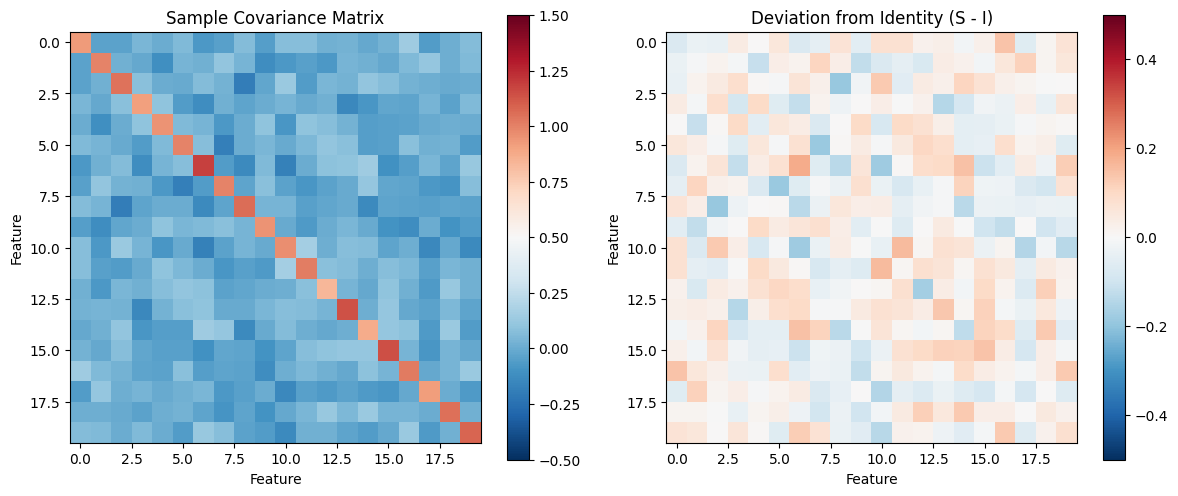

Frobenius norm of (S - I): 1.3942


In [3]:
# Visualize the sample covariance matrix
sample_cov = np.cov(X_identity, rowvar=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sample covariance heatmap
im1 = axes[0].imshow(sample_cov, cmap='RdBu_r', vmin=-0.5, vmax=1.5)
axes[0].set_title('Sample Covariance Matrix')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Feature')
plt.colorbar(im1, ax=axes[0])

# Difference from identity
diff = sample_cov - np.eye(p)
im2 = axes[1].imshow(diff, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[1].set_title('Deviation from Identity (S - I)')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Feature')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"Frobenius norm of (S - I): {np.linalg.norm(diff, 'fro'):.4f}")

In [4]:
# Run all identity tests on data with true identity covariance
print("="*60)
print("Testing H₀: Σ = I (NULL IS TRUE)")
print("="*60)

tests = [
    ("Ledoit-Wolf", ledoit_wolf_identity),
    ("Nagao", nagao_identity),
    ("Srivastava 2005", srivastava_2005_identity),
    ("Ahmad 2015", ahmad2015_identity),
    ("Tyler (trace)", lambda X: tyler_identity(X, method='tr')),
    ("Fisher", fisher_single_sample),
    ("Srivastava 2011", srivastava2011_single_sample),
]

results_null_true = []
for name, test_func in tests:
    try:
        result = test_func(X_identity)
        results_null_true.append((name, result['stat'], result['p_value']))
        decision = "Reject H₀" if result['p_value'] < 0.05 else "Fail to reject H₀"
        print(f"{name:20s}: stat={result['stat']:10.4f}, p-value={result['p_value']:.4f} → {decision}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:40]}")

print("\n✓ Expected: All tests should FAIL TO REJECT H₀ (p-value > 0.05)")

Testing H₀: Σ = I (NULL IS TRUE)
Ledoit-Wolf         : stat=  194.1089, p-value=0.7773 → Fail to reject H₀
Nagao               : stat=  194.3777, p-value=0.7732 → Fail to reject H₀
Srivastava 2005     : stat=   -0.7853, p-value=0.7839 → Fail to reject H₀
Ahmad 2015          : stat=   -1.1710, p-value=0.6641 → Fail to reject H₀
Tyler (trace)       : stat=   -0.1594, p-value=0.5633 → Fail to reject H₀
Fisher              : stat=   -0.5774, p-value=0.5637 → Fail to reject H₀
Srivastava 2011     : stat=   -0.8346, p-value=0.4039 → Fail to reject H₀

✓ Expected: All tests should FAIL TO REJECT H₀ (p-value > 0.05)


## 4. Example 2: Data with Non-Identity Covariance (Null is False)

In [5]:
# Generate data with AR(1) covariance structure - the null hypothesis is FALSE
n, p = 200, 20
rho = 0.7  # Strong autocorrelation

# Create Toeplitz (AR(1)) covariance
Sigma_ar1 = generate_toeplitz_cov(p, rho)

# Generate samples
X_ar1 = generate_heavy_tailed_samples(Sigma_ar1, n, dist_type='normal', rng=rng)

print(f"True covariance structure: AR(1) with ρ = {rho}")
print(f"Σ[i,j] = {rho}^|i-j|")

True covariance structure: AR(1) with ρ = 0.7
Σ[i,j] = 0.7^|i-j|


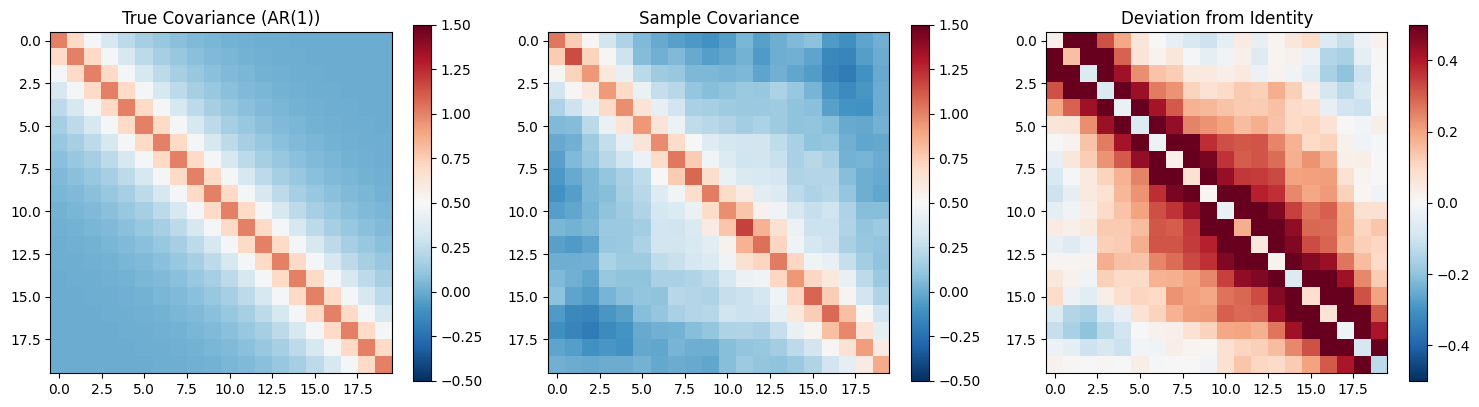

In [6]:
# Visualize the true and sample covariance
sample_cov_ar1 = np.cov(X_ar1, rowvar=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im1 = axes[0].imshow(Sigma_ar1, cmap='RdBu_r', vmin=-0.5, vmax=1.5)
axes[0].set_title('True Covariance (AR(1))')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(sample_cov_ar1, cmap='RdBu_r', vmin=-0.5, vmax=1.5)
axes[1].set_title('Sample Covariance')
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(sample_cov_ar1 - np.eye(p), cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[2].set_title('Deviation from Identity')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

In [7]:
# Run all identity tests on data with AR(1) covariance
print("="*60)
print("Testing H₀: Σ = I (NULL IS FALSE - AR(1) covariance)")
print("="*60)

results_null_false = []
for name, test_func in tests:
    try:
        result = test_func(X_ar1)
        results_null_false.append((name, result['stat'], result['p_value']))
        decision = "Reject H₀ ✓" if result['p_value'] < 0.05 else "Fail to reject H₀ ✗"
        print(f"{name:20s}: stat={result['stat']:10.4f}, p-value={result['p_value']:.4f} → {decision}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:40]}")

print("\n✓ Expected: All tests should REJECT H₀ (p-value < 0.05)")

Testing H₀: Σ = I (NULL IS FALSE - AR(1) covariance)
Ledoit-Wolf         : stat= 3853.2256, p-value=0.0000 → Reject H₀ ✓
Nagao               : stat= 3854.8943, p-value=0.0000 → Reject H₀ ✓
Srivastava 2005     : stat=  179.7633, p-value=0.0000 → Reject H₀ ✓
Ahmad 2015          : stat=  359.1553, p-value=0.0000 → Reject H₀ ✓
Tyler (trace)       : stat=  180.5279, p-value=0.0000 → Reject H₀ ✓
Fisher              : stat= 1154.7370, p-value=0.0000 → Reject H₀ ✓
Srivastava 2011     : stat=  180.3015, p-value=0.0000 → Reject H₀ ✓

✓ Expected: All tests should REJECT H₀ (p-value < 0.05)


## 5. Example 3: High-Dimensional Setting

In [8]:
# High-dimensional case: p is large relative to n
n_hd, p_hd = 100, 80  # p/n = 0.8

# Generate data with identity covariance (null true)
X_hd_null = rng.standard_normal(size=(n_hd, p_hd))

# Generate data with spiked covariance (null false)
Sigma_spiked = generate_spiked_covariance(p_hd, spike_eigenvalue=5.0, num_spikes=3, rng=rng)
X_hd_alt = generate_heavy_tailed_samples(Sigma_spiked, n_hd, 'normal', rng=rng)

print(f"High-dimensional setting: n={n_hd}, p={p_hd}, p/n={p_hd/n_hd:.2f}")

High-dimensional setting: n=100, p=80, p/n=0.80


In [9]:
# Compare test performance in high-dimensional setting
print("HIGH-DIMENSIONAL RESULTS (p/n = 0.8)")
print("="*70)

print("\n--- Null TRUE (Σ = I) ---")
for name, test_func in tests:
    try:
        result = test_func(X_hd_null)
        status = "✓" if result['p_value'] > 0.05 else "✗ (Type I error)"
        print(f"{name:20s}: p-value={result['p_value']:.4f} {status}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:30]}")

print("\n--- Null FALSE (Spiked covariance) ---")
for name, test_func in tests:
    try:
        result = test_func(X_hd_alt)
        status = "✓ (detected)" if result['p_value'] < 0.05 else "✗ (missed)"
        print(f"{name:20s}: p-value={result['p_value']:.4f} {status}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:30]}")

HIGH-DIMENSIONAL RESULTS (p/n = 0.8)

--- Null TRUE (Σ = I) ---
Ledoit-Wolf         : p-value=0.1339 ✓
Nagao               : p-value=0.0410 ✗ (Type I error)
Srivastava 2005     : p-value=0.1385 ✓
Ahmad 2015          : p-value=0.3706 ✓
Tyler (trace)       : p-value=0.1757 ✓
Fisher              : p-value=0.6660 ✓
Srivastava 2011     : p-value=0.4906 ✓

--- Null FALSE (Spiked covariance) ---
Ledoit-Wolf         : p-value=0.0000 ✓ (detected)
Nagao               : p-value=0.0000 ✓ (detected)
Srivastava 2005     : p-value=0.0000 ✓ (detected)
Ahmad 2015          : p-value=0.0000 ✓ (detected)
Tyler (trace)       : p-value=0.0000 ✓ (detected)
Fisher              : p-value=0.0000 ✓ (detected)
Srivastava 2011     : p-value=0.0000 ✓ (detected)


## 6. Example 4: Robustness to Heavy Tails

In [10]:
# Compare tests under heavy-tailed distributions
n, p = 150, 15
Sigma_identity = np.eye(p)

# Generate data with different tail behaviors
X_normal = generate_heavy_tailed_samples(Sigma_identity, n, 'normal', rng=rng)
X_t5 = generate_heavy_tailed_samples(Sigma_identity, n, 't', rng=rng, options={'df': 5})
X_t3 = generate_heavy_tailed_samples(Sigma_identity, n, 't', rng=rng, options={'df': 3})
X_laplace = generate_heavy_tailed_samples(Sigma_identity, n, 'laplace', rng=rng)

print("Generated data with identity covariance under different distributions:")
print("- Normal (light tails)")
print("- Student's t with df=5 (moderate tails)")
print("- Student's t with df=3 (heavy tails)")
print("- Laplace (heavier tails than normal)")

Generated data with identity covariance under different distributions:
- Normal (light tails)
- Student's t with df=5 (moderate tails)
- Student's t with df=3 (heavy tails)
- Laplace (heavier tails than normal)


In [11]:
# Test robustness across distributions
distributions = [
    ("Normal", X_normal),
    ("t (df=5)", X_t5),
    ("t (df=3)", X_t3),
    ("Laplace", X_laplace),
]

# Focus on key tests
key_tests = [
    ("Ledoit-Wolf", ledoit_wolf_identity),
    ("Nagao", nagao_identity),
    ("Tyler", lambda X: tyler_identity(X, method='tr')),
]

print("ROBUSTNESS COMPARISON (Null is TRUE for all)")
print("="*70)
print(f"{'Test':<15}", end="")
for dist_name, _ in distributions:
    print(f"{dist_name:>12}", end="")
print()
print("-"*70)

for test_name, test_func in key_tests:
    print(f"{test_name:<15}", end="")
    for dist_name, X_data in distributions:
        try:
            result = test_func(X_data)
            pval = result['p_value']
            # Good if p > 0.05 (don't reject true null)
            status = "✓" if pval > 0.05 else "✗"
            print(f"{pval:>10.3f}{status:>2}", end="")
        except:
            print(f"{'Error':>12}", end="")
    print()

print("\n✓ = Correctly failed to reject, ✗ = False rejection")
print("Note: Tyler's test is designed to be robust to heavy tails")

ROBUSTNESS COMPARISON (Null is TRUE for all)
Test                 Normal    t (df=5)    t (df=3)     Laplace
----------------------------------------------------------------------
Ledoit-Wolf         0.351 ✓     0.011 ✗     0.003 ✗     0.020 ✗
Nagao               0.215 ✓     0.002 ✗     0.058 ✓     0.004 ✗
Tyler               0.419 ✓     0.203 ✓     0.292 ✓     0.073 ✓

✓ = Correctly failed to reject, ✗ = False rejection
Note: Tyler's test is designed to be robust to heavy tails


## 7. Real Data Example: Iris Dataset

In [12]:
# Load Iris dataset
X_iris, y_iris, feature_names, target_names = load_iris(return_names=True)

print(f"Iris dataset shape: {X_iris.shape}")
print(f"Features: {list(feature_names)}")
print(f"Classes: {list(target_names)}")

Iris dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa', 'versicolor', 'virginica']


In [13]:
# Standardize the data (center and scale to unit variance)
X_iris_std = (X_iris - X_iris.mean(axis=0)) / X_iris.std(axis=0)

print("After standardization:")
print(f"Mean: {X_iris_std.mean(axis=0)}")
print(f"Std:  {X_iris_std.std(axis=0)}")

# Sample covariance of standardized data
sample_cov_iris = np.cov(X_iris_std, rowvar=False)
print(f"\nSample covariance matrix:\n{sample_cov_iris.round(3)}")

After standardization:
Mean: [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Std:  [1. 1. 1. 1.]

Sample covariance matrix:
[[ 1.007 -0.118  0.878  0.823]
 [-0.118  1.007 -0.431 -0.369]
 [ 0.878 -0.431  1.007  0.969]
 [ 0.823 -0.369  0.969  1.007]]


In [14]:
# Test if standardized Iris data has identity covariance
print("Testing H₀: Σ = I for standardized Iris data")
print("="*60)

for name, test_func in tests:
    try:
        result = test_func(X_iris_std)
        decision = "Reject H₀" if result['p_value'] < 0.05 else "Fail to reject H₀"
        print(f"{name:20s}: p-value={result['p_value']:.4f} → {decision}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:40]}")

print("\n→ Iris features are correlated even after standardization!")
print("  Standardization gives unit variances but doesn't remove correlations.")

Testing H₀: Σ = I for standardized Iris data
Ledoit-Wolf         : p-value=0.0000 → Reject H₀
Nagao               : p-value=0.0000 → Reject H₀
Srivastava 2005     : p-value=0.0000 → Reject H₀
Ahmad 2015          : p-value=0.0000 → Reject H₀
Tyler (trace)       : p-value=0.0000 → Reject H₀
Fisher              : p-value=0.0000 → Reject H₀
Srivastava 2011     : p-value=0.0000 → Reject H₀

→ Iris features are correlated even after standardization!
  Standardization gives unit variances but doesn't remove correlations.


In [15]:
# Apply PCA whitening and test again
from sklearn.decomposition import PCA

# Whiten the data using PCA
pca = PCA(whiten=True)
X_iris_whitened = pca.fit_transform(X_iris)

print("After PCA whitening:")
sample_cov_whitened = np.cov(X_iris_whitened, rowvar=False)
print(f"Sample covariance matrix:\n{sample_cov_whitened.round(3)}")

print("\nTesting H₀: Σ = I for PCA-whitened Iris data")
print("="*60)

for name, test_func in tests[:4]:  # Test a subset
    try:
        result = test_func(X_iris_whitened)
        decision = "Reject H₀" if result['p_value'] < 0.05 else "Fail to reject H₀"
        print(f"{name:20s}: p-value={result['p_value']:.4f} → {decision}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:40]}")

print("\n→ After whitening, we fail to reject H₀: Σ = I")

After PCA whitening:
Sample covariance matrix:
[[ 1.  0.  0. -0.]
 [ 0.  1. -0. -0.]
 [ 0. -0.  1. -0.]
 [-0. -0. -0.  1.]]

Testing H₀: Σ = I for PCA-whitened Iris data
Ledoit-Wolf         : p-value=1.0000 → Fail to reject H₀
Nagao               : p-value=1.0000 → Fail to reject H₀
Srivastava 2005     : p-value=0.9934 → Fail to reject H₀
Ahmad 2015          : p-value=0.0795 → Fail to reject H₀

→ After whitening, we fail to reject H₀: Σ = I


## 8. Practical Guidelines

### Choosing the Right Test

| Scenario | Recommended Test |
|----------|------------------|
| Classical (n >> p, normal data) | `nagao_identity` |
| High-dimensional (p/n > 0.1) | `ledoit_wolf_identity`, `srivastava_2005_identity` |
| Heavy-tailed or outliers | `tyler_identity` |
| Very high-dimensional (p > n) | `ahmad2015_identity` |

### Interpretation Tips

1. **p-value < 0.05**: Reject H₀, evidence that Σ ≠ I
2. **p-value ≥ 0.05**: Fail to reject H₀, no strong evidence against Σ = I
3. **Multiple tests**: If results disagree, trust the test most appropriate for your setting

### Common Pitfalls

- **Standardization ≠ Whitening**: Standardizing to unit variance doesn't remove correlations
- **Sample size matters**: Small samples lead to noisy estimates
- **Distributional assumptions**: Classical tests may fail under heavy tails

## 9. Summary

This tutorial demonstrated:

1. How to test if a covariance matrix equals the identity
2. Behavior under null (true) and alternative (false) hypotheses
3. Performance in high-dimensional settings
4. Robustness to heavy-tailed distributions
5. Application to real data (Iris dataset)

**Key takeaways:**
- Use `ledoit_wolf_identity` for high-dimensional data
- Use `tyler_identity` when data may have outliers or heavy tails
- Use `nagao_identity` for classical settings with n >> p